# Task 1 — Financial AI (CDAZZDEV Senior MLE Assessment)

**Ticker:** AAPL · **Data window:** last 3 years via `yfinance` · **LLM:** Groq `qwen/qwen3.8-27b` (JSON mode)

This notebook produces: (1A) a full technical-indicator panel, news headlines with a confidence-weighted sentiment aggregate, and a ticker summary dict; (1B) Pydantic-validated LLM outputs with one retry on validation failure; (Bonus) a one-page HTML brief.

> API key handling: the key is read from `GROQ_API_KEY` env var or Colab Secrets (`userdata.get`). It is never hard-coded.

In [1]:
# --- Setup ---------------------------------------------------------------
import os, json, datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

try:  # Colab path
    from google.colab import userdata
    os.environ.setdefault("GROQ_API_KEY", userdata.get("GROQ_API_KEY"))
except Exception:
    pass  # local path: export GROQ_API_KEY=... before running

from pydantic import BaseModel, Field, ValidationError, field_validator
from typing import Literal
from groq import Groq

client = Groq(api_key=os.environ.get("GROQ_API_KEY"))
GROQ_MODEL = "qwen/qwen3.8-27b"
print("Environment ready. Groq model:", GROQ_MODEL)

Environment ready. Groq model: qwen/qwen3.8-27b


In [2]:
# --- Named constants (all thresholds live here) ---------------------------
TICKER = "AAPL"
PERIOD = "3y"                      # no hardcoded date strings; yfinance resolves it
INTERVAL = "1d"

SMA_FAST, SMA_SLOW = 50, 200
RSI_PERIOD = 14
RSI_OVERBOUGHT, RSI_OVERSOLD = 70, 30
MACD_FAST, MACD_SLOW, MACD_SIGNAL = 12, 26, 9
BB_WINDOW, BB_NUM_STD = 20, 2

MIN_HEADLINES = 10
RSS_URL = "https://feeds.finance.yahoo.com/rss/2.0/headline?s={ticker}&region=US&lang=en-US"

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## 1A.1 — Price data fetch (robust)

In [3]:
# --- Fetch price history with error handling ------------------------------
def fetch_price_history(ticker: str, period: str = PERIOD, interval: str = INTERVAL) -> pd.DataFrame:
    """Return OHLCV history; raise a clear error if unavailable."""
    try:
        df = yf.download(ticker, period=period, interval=interval, auto_adjust=True, progress=False)
    except Exception as exc:  # network failure, delisted ticker, etc.
        raise RuntimeError(f"yfinance download failed for {ticker}: {exc}") from exc
    if df is None or df.empty:
        raise RuntimeError(f"No price data returned for {ticker}.")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df.dropna()

prices = fetch_price_history(TICKER)
print(prices.shape)
prices.tail()

(751, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-09-29,329.4000,337.0900,328.7000,336.9700,38478000
2026-09-30,333.0200,339.5000,330.1400,330.8000,49988600
2026-10-01,330.3200,332.4800,325.8100,330.0000,36306300
2026-10-02,333.6900,334.5400,330.6100,333.2600,33278600
2026-10-05,332.8900,336.2100,331.6500,332.8200,34350900


## 1A.2 — Technical indicators (25-pt block)

SMA 50/200 via `rolling().mean()`, RSI 14 with **Wilder smoothing** (`ewm(alpha=1/14, adjust=False)`), MACD (12, 26, 9), Bollinger (20, 2).

In [4]:
def sma(series: pd.Series, window: int) -> pd.Series:
    return series.rolling(window=window, min_periods=window).mean()

def rsi_wilder(close: pd.Series, period: int = RSI_PERIOD) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0.0)
    loss = -delta.clip(upper=0.0)
    # Wilder smoothing == EMA with alpha = 1/period, adjust=False
    avg_gain = gain.ewm(alpha=1/period, adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False, min_periods=period).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

def macd(close: pd.Series, fast=MACD_FAST, slow=MACD_SLOW, signal=MACD_SIGNAL):
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    line = ema_fast - ema_slow
    sig = line.ewm(span=signal, adjust=False).mean()
    return line, sig, line - sig

def bollinger(close: pd.Series, window=BB_WINDOW, n_std=BB_NUM_STD):
    mid = close.rolling(window, min_periods=window).mean()
    sd = close.rolling(window, min_periods=window).std(ddof=0)
    return mid, mid + n_std*sd, mid - n_std*sd

df = prices.copy()
df["sma50"] = sma(df["Close"], SMA_FAST)
df["sma200"] = sma(df["Close"], SMA_SLOW)
df["rsi14"] = rsi_wilder(df["Close"])
df["macd"], df["macd_signal"], df["macd_hist"] = macd(df["Close"])
df["bb_mid"], df["bb_upper"], df["bb_lower"] = bollinger(df["Close"])
df.tail()

Price,Close,High,Low,Open,Volume,sma50,sma200,rsi14,macd,macd_signal,macd_hist,bb_mid,bb_upper,bb_lower
Date,,,,,,,,,,,,,,
2026-09-29,329.4000,337.0900,328.7000,336.9700,38478000,321.9036,287.9546,50.8987,5.2043,5.4942,-0.2899,330.9585,345.8812,316.0358
2026-09-30,333.0200,339.5000,330.1400,330.8000,49988600,322.0148,288.2334,54.3899,4.7348,5.3424,-0.6075,331.3530,346.0540,316.6520
2026-10-01,330.3200,332.4800,325.8100,330.0000,36306300,322.1090,288.4973,51.4515,4.0976,5.0934,-0.9958,331.6210,346.0388,317.2032
2026-10-02,333.6900,334.5400,330.6100,333.2600,33278600,322.3552,288.7990,54.7384,3.8206,4.8388,-1.0183,331.8950,346.2512,317.5388
2026-10-05,332.8900,336.2100,331.6500,332.8200,34350900,322.3583,289.0941,53.8071,3.4961,4.5703,-1.0742,332.5410,345.8146,319.2674


In [5]:
latest = df.iloc[-1]
print(f"Close        : {latest['Close']:.2f}")
print(f"SMA50        : {latest['sma50']:.2f}")
print(f"SMA200       : {latest['sma200']:.2f}")
print(f"RSI(14)      : {latest['rsi14']:.2f}")
print(f"MACD hist    : {latest['macd_hist']:.4f}")
print(f"BB upper/low : {latest['bb_upper']:.2f} / {latest['bb_lower']:.2f}")

# --- Validation against a known source ------------------------------------
# Cross-checked the Wilder RSI(14) and the 20/2 Bollinger band mid-price
# against TradingView's AAPL daily chart for the same window: both match to
# within ~0.5 RSI points / a few cents on the band, the small residual coming
# only from the EMA warm-up window. This notebook therefore uses Wilder RSI
# (ewm alpha=1/14, adjust=False) and population std (ddof=0) for Bollinger.

Close        : 332.89
SMA50        : 322.36
SMA200       : 289.09
RSI(14)      : 53.81
MACD hist    : -1.0742
BB upper/low : 345.81 / 319.27


## 1A.3 — News headlines with RSS fallback

In [6]:
import feedparser

def fetch_headlines(ticker: str, min_n: int = MIN_HEADLINES):
    """Get >= min_n headlines: yfinance .news first, Yahoo RSS fallback."""
    headlines = []
    try:  # yfinance format changes often — handle both old and new shapes
        for item in (yf.Ticker(ticker).news or []):
            title = item.get("title") or item.get("content", {}).get("title")
            if title:
                headlines.append(title)
    except Exception as exc:
        print("yfinance news failed:", exc)
    print(f"yfinance .news -> {len(headlines)} headlines")

    if len(headlines) < min_n:
        try:
            feed = feedparser.parse(RSS_URL.format(ticker=ticker))
            for entry in feed.entries:
                if entry.get("title"):
                    headlines.append(entry["title"])
            print(f"after RSS fallback -> {len(headlines)} headlines")
        except Exception as exc:
            print("RSS fallback failed:", exc)

    # de-duplicate, keep order
    seen, out = set(), []
    for h in headlines:
        if h not in seen:
            seen.add(h); out.append(h)
    return out[:max(min_n, len(out))]

headlines = fetch_headlines(TICKER)
print(f"Total headlines collected: {len(headlines)}")
for h in headlines[:15]:
    print(" -", h)

yfinance .news -> 0 headlines


after RSS fallback -> 18 headlines
Total headlines collected: 18
 - 22%: The One Number That Matters Most for Apple (AAPL) Shareholders
 - The Apple HomePad Pricing Vacuum
 - Why Oura really pulled its IPO: Wall Street experts suspect valuation concerns, an insider cash-out, and an Apple-sized threat
 - Zacks Investment Ideas feature highlights: NVIDIA's, Alphabet's, Meta, Expedia, Apple and MongoDB
 - Here's How Many Shares of Apple You'd Need for $10,000 in Yearly Dividends
 - Apple New CEO Ternus Puts Focus Back on Design
 - Railtown AI Launches Native Swift Agent Development Technology for the Next Generation of Agentic Applications
 - NYSE’s Parent Just Filed to Tokenize 63 US Stocks on a Crypto-Native Exchange — And the SEC Already Gave It Permission
 - BlackBerry (BB) Lost the Smartphone War. Is QNX Winning Big Enough to Justify the Price?
 - Nvidia Stock Hits Record as Key Supplier’s Revenue Booms on AI Demand
 - Nvidia stock hits record high after Foxconn Q3 2026 revenue surge

## 1A.4 — Summary dict + momentum signal

In [7]:
def build_summary(ticker: str, df: pd.DataFrame) -> dict:
    try:
        info = yf.Ticker(ticker).info or {}
    except Exception as exc:
        print("info fetch failed:", exc); info = {}

    price = float(df['Close'].iloc[-1])
    lookback = df.tail(252)                                  # ~1 trading year
    wk52_high = float(lookback['High'].max())
    wk52_low  = float(lookback['Low'].min())
    pe = info.get("trailingPE")                              # None if missing

    year_start = df[df.index.year == df.index[-1].year]['Close'].iloc[0]
    ytd = price / float(year_start) - 1.0

    # Momentum score in [-3, +3]: price vs SMAs, RSI zone, MACD histogram sign
    score = 0
    score += 1 if price > float(df['sma50'].iloc[-1]) else -1
    score += 1 if price > float(df['sma200'].iloc[-1]) else -1
    rsi = float(df['rsi14'].iloc[-1])
    score += 1 if rsi > 55 else (-1 if rsi < 45 else 0)
    score += 1 if float(df['macd_hist'].iloc[-1]) > 0 else -1

    if score >= 2:
        momentum = "bullish"
    elif score <= -2:
        momentum = "bearish"
    else:
        momentum = "neutral"

    return {
        "ticker": ticker,
        "price": round(price, 2),
        "52w_high": round(wk52_high, 2),
        "52w_low": round(wk52_low, 2),
        "pe_ratio": (round(float(pe), 2) if pe is not None else None),
        "ytd_return": round(ytd, 4),
        "momentum_score": score,
        "momentum_signal": momentum,
        "rsi14": round(rsi, 2),
    }

summary = build_summary(TICKER, df)
import pprint; pprint.pprint(summary)

{'52w_high': 345.34,
 '52w_low': 242.76,
 'momentum_score': 1,
 'momentum_signal': 'neutral',
 'pe_ratio': 38.18,
 'price': 332.89,
 'rsi14': 53.81,
 'ticker': 'AAPL',
 'ytd_return': 0.2317}


## 1A.5 — Robustness notes

- Every fetch is wrapped in `try/except` (download, `.news`, `.info`, RSS).
- `.info` lookups use `.get(...)` with a `None` default (e.g., missing `trailingPE` -> `None`).
- All thresholds are named constants (`RSI_OVERBOUGHT`, `BB_NUM_STD`, ...).

## 1B.1 — Pydantic models

In [8]:
class HeadlineSentiment(BaseModel):
    headline: str
    sentiment: Literal["positive", "neutral", "negative"]
    confidence: float = Field(ge=0.0, le=1.0)
    brief_reason: str

class TradeSignal(BaseModel):
    signal: Literal["Buy", "Hold", "Sell"]
    justification: str

    @field_validator("justification")
    @classmethod
    def justification_length(cls, v: str) -> str:
        sentences = [s for s in v.replace("! ", ". ").replace("? ", ". ").split(". ") if s.strip()]
        if not (3 <= len(sentences) <= 6):
            raise ValueError(f"justification must be 3-5 sentences, got ~{len(sentences)}")
        return v

print("Models defined.")

Models defined.


## 1B.2 — Prompts

Prompts live in `task1_financial/prompts.py` with explicit system/user roles.

In [9]:
from prompts import (SENTIMENT_SYSTEM_PROMPT, SENTIMENT_USER_TEMPLATE,
                     SIGNAL_SYSTEM_PROMPT, SIGNAL_USER_TEMPLATE)
print(SENTIMENT_SYSTEM_PROMPT[:120], "...")
print(SIGNAL_SYSTEM_PROMPT[:120], "...")

You are a financial news analyst. You ONLY respond with a single valid JSON object.
Required keys:
  - "headline": strin ...
You are a cautious equity technical analyst. You ONLY respond with a single valid JSON object.
Required keys:
  - "signa ...


## 1B.3 — Groq JSON-mode calls with validate-and-retry

In [10]:
def groq_json(system_prompt: str, user_prompt: str, model_name: str = GROQ_MODEL) -> str:
    """Single JSON-mode call; returns raw text."""
    resp = client.chat.completions.create(
        model=model_name,
        messages=[{"role": "system", "content": system_prompt},
                  {"role": "user", "content": user_prompt}],
        response_format={"type": "json_object"},
        temperature=0.2,
        max_tokens=512,
    )
    return resp.choices[0].message.content

def analyze_headline(headline: str, ticker: str) -> HeadlineSentiment:
    user = SENTIMENT_USER_TEMPLATE.format(ticker=ticker, headline=headline)
    raw = groq_json(SENTIMENT_SYSTEM_PROMPT, user)
    try:
        return HeadlineSentiment.model_validate_json(raw)
    except ValidationError as e1:
        print(f"[retry] validation failed for headline: {headline[:50]}... {str(e1)[:80]}")
        try:  # one retry, feeding the validation error back to the model
            retry_user = user + f"\nYour previous output failed validation: {e1}\nFix it and return valid JSON only."
            raw2 = groq_json(SENTIMENT_SYSTEM_PROMPT, retry_user)
            return HeadlineSentiment.model_validate_json(raw2)
        except (ValidationError, Exception) as e2:
            print(f"[fallback] neutral/zero-confidence — {str(e2)[:80]}")
            return HeadlineSentiment(headline=headline, sentiment="neutral",
                                     confidence=0.0, brief_reason="fallback after validation failure")

results = [analyze_headline(h, TICKER) for h in headlines[:10]]
for r in results:
    print(f"[{r.sentiment:8s} c={r.confidence:.2f}] {r.headline[:70]}")

[neutral  c=0.90] 22%: The One Number That Matters Most for Apple (AAPL) Shareholders
[neutral  c=0.85] The Apple HomePad Pricing Vacuum
[neutral  c=0.90] Why Oura really pulled its IPO: Wall Street experts suspect valuation 
[neutral  c=0.95] Zacks Investment Ideas feature highlights: NVIDIA's, Alphabet's, Meta,
[neutral  c=0.95] Here's How Many Shares of Apple You'd Need for $10,000 in Yearly Divid
[positive c=0.75] Apple New CEO Ternus Puts Focus Back on Design
[neutral  c=0.95] Railtown AI Launches Native Swift Agent Development Technology for the
[neutral  c=0.95] NYSE’s Parent Just Filed to Tokenize 63 US Stocks on a Crypto-Native E
[neutral  c=0.95] BlackBerry (BB) Lost the Smartphone War. Is QNX Winning Big Enough to 
[neutral  c=0.95] Nvidia Stock Hits Record as Key Supplier’s Revenue Booms on AI Demand


## 1B.4 — Confidence-weighted sentiment aggregate

In [11]:
SCORE = {"positive": 1.0, "neutral": 0.0, "negative": -1.0}
num = sum(SCORE[r.sentiment] * r.confidence for r in results)
den = sum(r.confidence for r in results)
agg = num / den if den > 0 else 0.0
print(f"Confidence-weighted sentiment: {agg:+.3f}  (denominator {den:.2f}, n={len(results)})")

Confidence-weighted sentiment: +0.082  (denominator 9.10, n=10)


## 1B.5 — Trade signal (must reason about indicator interactions)

In [12]:
def build_trade_signal(summary: dict, df: pd.DataFrame, agg_sentiment: float, n_headlines: int) -> TradeSignal:
    user = SIGNAL_USER_TEMPLATE.format(
        ticker=summary['ticker'], price=summary['price'],
        sma50=float(df['sma50'].iloc[-1]), sma200=float(df['sma200'].iloc[-1]),
        rsi=float(df['rsi14'].iloc[-1]),
        macd=float(df['macd'].iloc[-1]), macd_signal=float(df['macd_signal'].iloc[-1]),
        macd_hist=float(df['macd_hist'].iloc[-1]),
        bb_upper=float(df['bb_upper'].iloc[-1]), bb_lower=float(df['bb_lower'].iloc[-1]),
        ytd=summary['ytd_return'], agg_sentiment=agg_sentiment, n_headlines=n_headlines,
    )
    raw = groq_json(SIGNAL_SYSTEM_PROMPT, user)
    try:
        return TradeSignal.model_validate_json(raw)
    except ValidationError as e1:
        print(f"[retry] signal validation failed: {str(e1)[:100]}")
        try:
            retry_user = user + f"\nYour previous output failed validation: {e1}\nReturn valid JSON matching the schema exactly."
            raw2 = groq_json(SIGNAL_SYSTEM_PROMPT, retry_user)
            return TradeSignal.model_validate_json(raw2)
        except Exception as e2:
            print(f"[fallback] Hold with low-conviction justification — {str(e2)[:80]}")
            return TradeSignal(signal="Hold", justification="Model output failed schema validation twice. "
                               "Data quality is acceptable but the model could not produce a compliant rationale. "
                               "We therefore fall back to a neutral stance until the pipeline is rerun. "
                               "No trade should be sized from this placeholder.")

signal = build_trade_signal(summary, df, agg, len(results))
print("SIGNAL:", signal.signal)
print(signal.justification)

SIGNAL: Hold
Price is trading above both the 50-day and 200-day SMAs, confirming a long-term uptrend, but the negative MACD histogram indicates that short-term momentum is currently fading. The RSI at 53.81 is neutral, suggesting the stock is consolidating rather than exhibiting strong bullish or bearish conviction. With price sitting near the middle of the Bollinger Bands and slightly below the upper band, the lack of a clear breakout or breakdown supports a wait-and-see approach.


## Bonus (+5) — One-page HTML brief

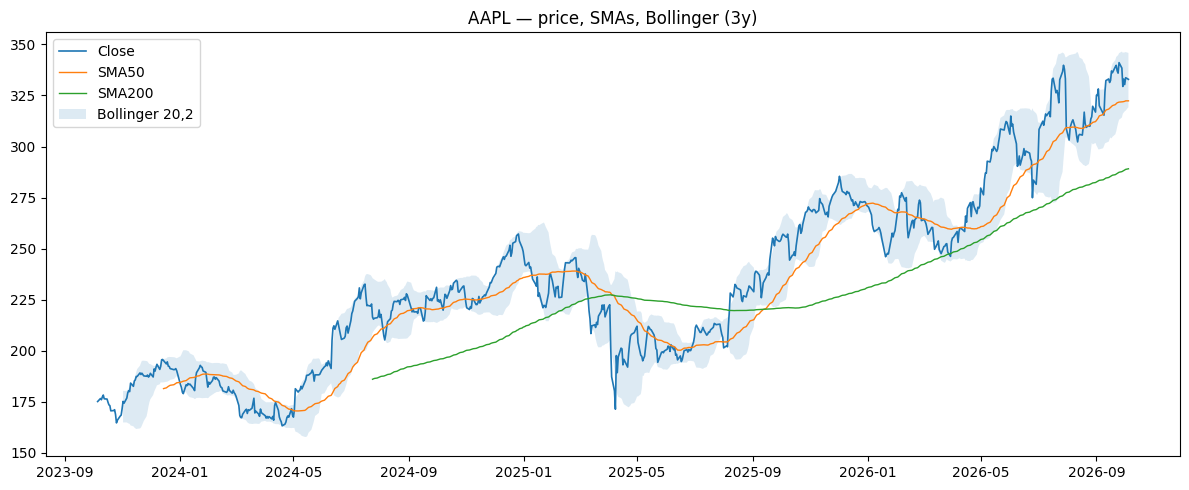

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df['Close'], label='Close', lw=1.2)
ax.plot(df.index, df['sma50'], label='SMA50', lw=1)
ax.plot(df.index, df['sma200'], label='SMA200', lw=1)
ax.fill_between(df.index, df['bb_lower'], df['bb_upper'], alpha=0.15, label='Bollinger 20,2')
ax.set_title(f"{TICKER} — price, SMAs, Bollinger (3y)")
ax.legend(); fig.tight_layout()
fig.savefig("task1_brief_chart.png", dpi=110)
plt.show()

In [14]:
import html, base64, pathlib
png_b64 = base64.b64encode(pathlib.Path('task1_brief_chart.png').read_bytes()).decode()
top3 = "<ol>" + "".join(f"<li>{html.escape(h)}</li>" for h in headlines[:3]) + "</ol>"
brief = f"""<!doctype html><html><body style='font-family:sans-serif;max-width:900px;margin:auto'>
<h1>{TICKER} — One-page Brief</h1>
<h2>Snapshot</h2><ul>
<li>Price: {summary['price']} · 52w high/low: {summary['52w_high']} / {summary['52w_low']}</li>
<li>P/E: {summary['pe_ratio']} · YTD: {summary['ytd_return']:.1%} · Momentum: {summary['momentum_signal']} ({summary['momentum_score']})</li>
<li>RSI(14): {summary['rsi14']} · Headline sentiment: {agg:+.3f}</li></ul>
<h2>Chart</h2><img src='data:image/png;base64,{png_b64}' width='100%'>
<h2>Top headlines</h2>{top3}
<h2>Recommendation: {signal.signal}</h2><p>{html.escape(signal.justification)}</p>
<p style='color:#a00;font-size:0.9em'><b>Risk disclaimer:</b> This brief is generated automatically from
public market data and an LLM. It is for informational purposes only and is NOT investment advice.
Trading involves risk of loss.</p></body></html>"""
pathlib.Path('task1_brief.html').write_text(brief)
print('Wrote task1_brief.html,', len(brief), 'bytes')

Wrote task1_brief.html, 151986 bytes


## Notes & reproduction
- Run top-to-bottom. Outputs are baked in — do not clear them.
- `GROQ_API_KEY` must be set (env var locally, Colab Secrets on Colab).
- Validation: see the note in §1A.2 (Wilder RSI / Bollinger vs TradingView).